In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

raw = pd.read_excel("last_amb_hour_time.xls", engine="xlrd")

df = raw.iloc[5:].copy()
df.columns = [
    "날짜",
    "PM10_등급", "PM10",
    "PM25_등급", "PM25",
    "오존_등급",  "O3",
    "NO2_등급",  "NO2",
    "CO_등급",   "CO",
    "SO2_등급",  "SO2",
]
df = df.reset_index(drop=True)

def parse_date(s):
    date_part, hour = s.rsplit(":", 1)
    hour = int(hour)
    if hour == 24:
        return pd.to_datetime(date_part) + pd.Timedelta(days=1)
    return pd.to_datetime(f"{date_part} {hour:02d}:00")

df["날짜"] = df["날짜"].apply(parse_date)

for col in ["PM10", "PM25", "O3", "NO2", "CO", "SO2"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("데이터 로드 완료!")
print(df.shape)

데이터 로드 완료!
(150, 13)


## 1. 📈 대기오염 물질 시간별 추이 (2026.05.17 ~ 05.23)

6가지 대기오염 물질의 1시간 단위 측정값 변화를 살펴봅니다.  
기준선을 함께 표시해 전반적인 오염 수준을 파악합니다.

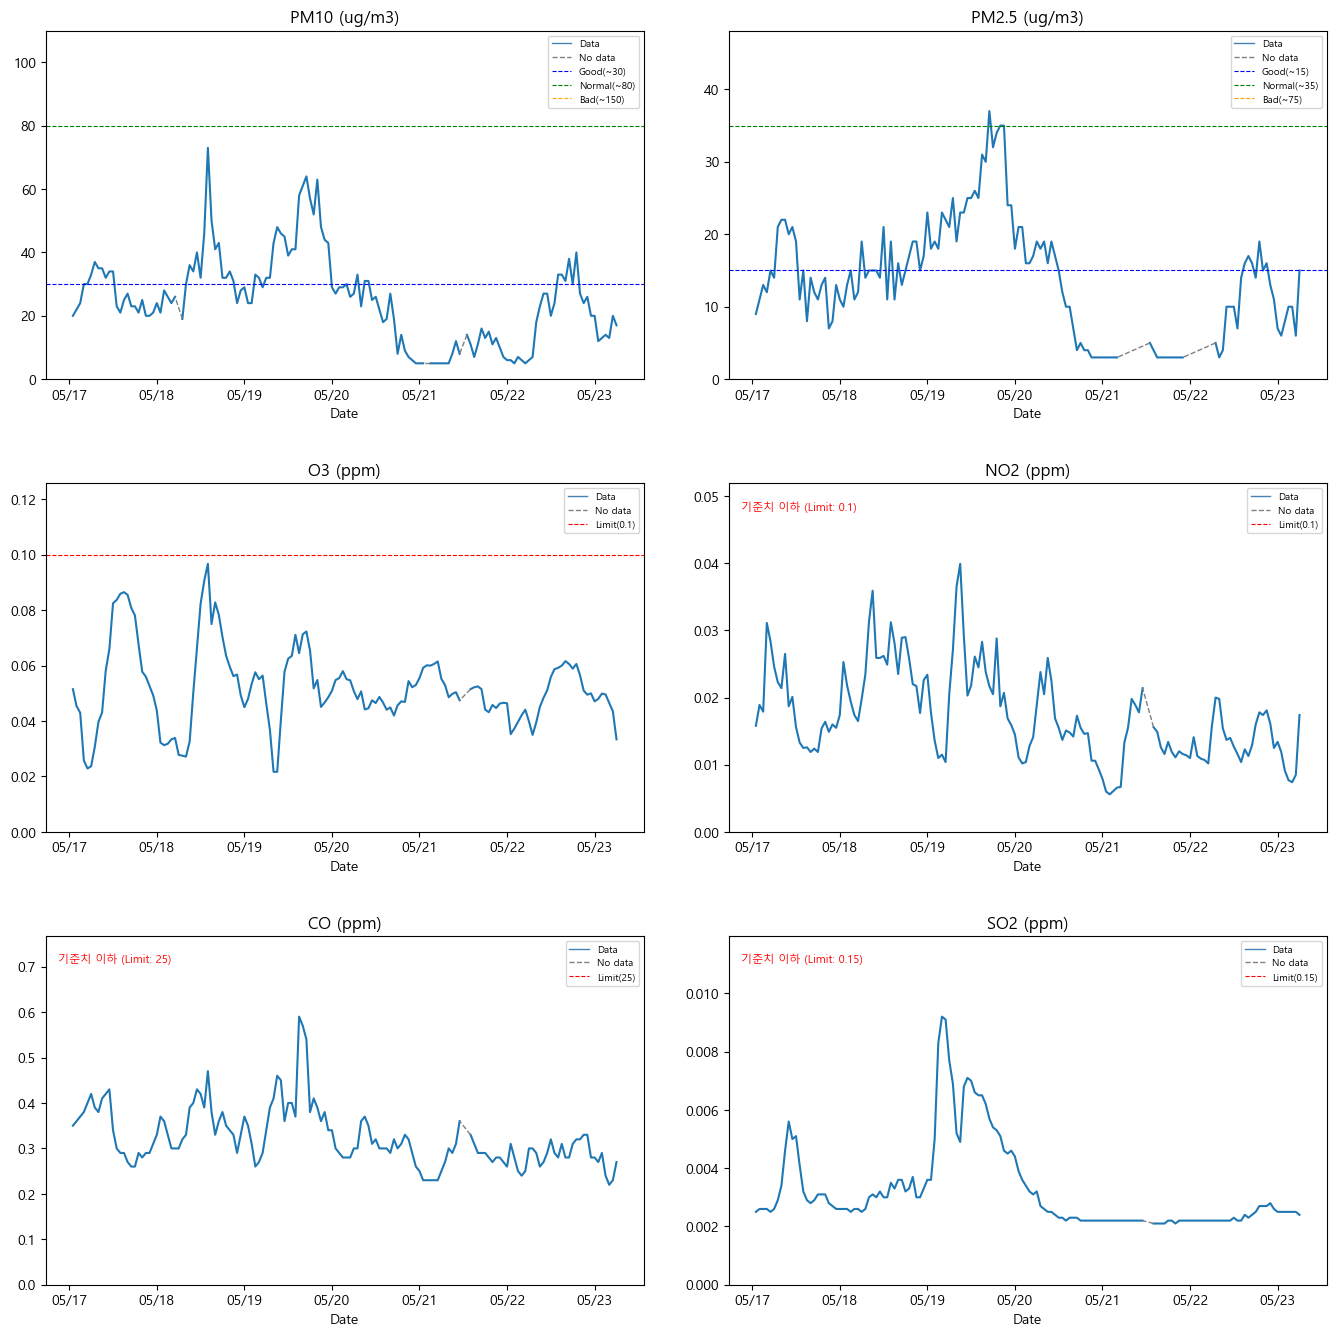

In [60]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
from matplotlib.lines import Line2D

limits = {
    "PM10": 100,
    "PM25": 35,
    "O3":   0.1,
    "NO2":  0.10,
    "CO":   25,
    "SO2":  0.15,
}

items = [
    ("PM10",  "PM10 (ug/m3)",  axes[0, 0]),
    ("PM25",  "PM2.5 (ug/m3)", axes[0, 1]),
    ("O3",    "O3 (ppm)",      axes[1, 0]),
    ("NO2",   "NO2 (ppm)",     axes[1, 1]),
    ("CO",    "CO (ppm)",      axes[2, 0]),
    ("SO2",   "SO2 (ppm)",     axes[2, 1]),
]

for col, label, ax in items:
    ax.plot(df["날짜"], df[col])
    ax.set_title(label)
    ax.set_xlabel("Date")
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%m/%d"))
    ax.xaxis.set_major_locator(plt.matplotlib.dates.DayLocator())
    ax.tick_params(axis="x")

    ymax = df[col].dropna().max()
    if col in ["NO2", "CO", "SO2"]:
        ax.set_ylim(0, ymax * 1.3)
    else:
        ax.set_ylim(0, max(ymax * 1.3, limits[col] * 1.1))

        
    if col == "PM10":
        ax.axhline(y=30,  color="blue",   linestyle="--", linewidth=0.8, label="Good(~30)")
        ax.axhline(y=80,  color="green",  linestyle="--", linewidth=0.8, label="Normal(~80)")
        ax.axhline(y=150, color="orange", linestyle="--", linewidth=0.8, label="Bad(~150)")
    elif col == "PM25":
        ax.axhline(y=15, color="blue",   linestyle="--", linewidth=0.8, label="Good(~15)")
        ax.axhline(y=35, color="green",  linestyle="--", linewidth=0.8, label="Normal(~35)")
        ax.axhline(y=75, color="orange", linestyle="--", linewidth=0.8, label="Bad(~75)")
    elif col == "O3":
        ax.axhline(y=limits[col], color="red", linestyle="--", linewidth=0.8, label=f"Limit({limits[col]})")
    else:
        ax.text(0.02, 0.95, f"기준치 이하 (Limit: {limits[col]})",
               transform=ax.transAxes, fontsize=8, color="red", va="top")
        
        
    missing = df[col].isna()
    in_gap = False
    gap_start_idx = None
    first_nodata = True

    for i, is_missing in enumerate(missing):
        if is_missing and not in_gap:
            gap_start_idx = i - 1
            in_gap = True
        elif not is_missing and in_gap:
            x = [df["날짜"].iloc[gap_start_idx], df["날짜"].iloc[i]]
            y = [df[col].iloc[gap_start_idx], df[col].iloc[i]]
            ax.plot(x, y, color="gray", linestyle="--", linewidth=1, label="No data" if first_nodata else "")
            in_gap = False
            first_nodata = False

    legend_elements = [
    Line2D([0], [0], color="steelblue", linewidth=1, linestyle="-",  label="Data"),
    Line2D([0], [0], color="gray",      linewidth=1, linestyle="--", label="No data"),
    ]

    if col == "PM10":
        legend_elements.append(Line2D([0], [0], color="blue",   linestyle="--", linewidth=0.8, label="Good(~30)"))
        legend_elements.append(Line2D([0], [0], color="green",  linestyle="--", linewidth=0.8, label="Normal(~80)"))
        legend_elements.append(Line2D([0], [0], color="orange", linestyle="--", linewidth=0.8, label="Bad(~150)"))
    elif col == "PM25":
        legend_elements.append(Line2D([0], [0], color="blue",   linestyle="--", linewidth=0.8, label="Good(~15)"))
        legend_elements.append(Line2D([0], [0], color="green",  linestyle="--", linewidth=0.8, label="Normal(~35)"))
        legend_elements.append(Line2D([0], [0], color="orange", linestyle="--", linewidth=0.8, label="Bad(~75)"))
    else:
        legend_elements.append(Line2D([0], [0], color="red", linestyle="--", linewidth=0.8, label=f"Limit({limits[col]})"))

    ax.legend(handles=legend_elements, fontsize=7, loc="upper right")

plt.tight_layout(pad=3.0)
plt.show()

## 2. 📊 평일 vs 주말 PM2.5 분석

서울역 앞 한강대로는 출퇴근 차량이 많은 도로입니다.  
평일과 주말의 PM2.5 농도 차이를 비교해 차량 배기가스의 영향을 확인합니다.

C:\Users\AISW_203_103\AppData\Local\Temp\ipykernel_11948\346752629.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="평일_주말", y="PM25", data=df, palette="Set2", ax=ax)


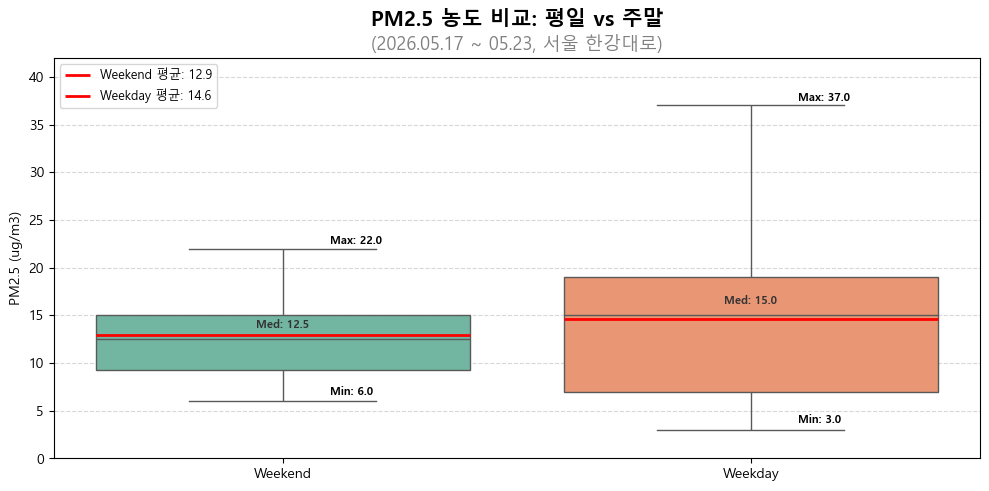

In [45]:
df["요일"] = df["날짜"].dt.weekday
df["평일_주말"] = df["요일"].apply(lambda x: "Weekend" if x >= 5 else "Weekday")

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(x="평일_주말", y="PM25", data=df, palette="Set2", ax=ax)

categories = ["Weekend", "Weekday"]
for i, group in enumerate(categories):
    data = df[df["평일_주말"] == group]["PM25"].dropna()
    mean_val   = data.mean()
    median_val = data.median()
    max_val    = data.max()
    min_val    = data.min()

    # 평균선
    ax.hlines(mean_val, i - 0.4, i + 0.4, color="red", linewidth=2,
              label=f"{group} 평균: {mean_val:.1f}" )

    # 수치 표시
    ax.text(i + 0.1, max_val + 0.8,    f"Max: {max_val:.1f}",    va="center", fontsize=8, fontweight="bold")
    ax.text(i + 0.1, min_val  + 1.0,    f"Min: {min_val:.1f}",    va="center", fontsize=8, fontweight="bold")
    ax.text(i, median_val + 1.5 , f"Med: {median_val:.1f}", va="center",  ha="center", fontsize=8, color="#333333", fontweight="bold")

ax.set_title("")  # 기존 제목 비우기
ax.text(0.5, 1.08, "PM2.5 농도 비교: 평일 vs 주말",
        transform=ax.transAxes, ha="center", fontsize=15, fontweight="bold")
ax.text(0.5, 1.02, "(2026.05.17 ~ 05.23, 서울 한강대로)",
        transform=ax.transAxes, ha="center", fontsize=13, color="gray")
ax.set_ylabel("PM2.5 (ug/m3)")
ax.set_xlabel("")
ax.set_ylim(0, df["PM25"].max() + 5)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 📝 결과 해석

<span style="color: gray; font-size: 0.85em;">
박스플롯 읽는 법: 가운데 선 = 중앙값 / 박스 = 데이터 50% 범위 / 수염 = 최댓값·최솟값
</span>

**분석 결과**
- 평일 평균: 14.6 ug/m3
- 주말 평균: 12.9 ug/m3
- 평일이 주말보다 약 1.7 높음
- 차량 통행량이 PM2.5에 영향을 준다고 볼 수 있음

## 3. 🔗 대기오염 물질 간 상관관계 분석

PM2.5 상승의 원인이 차량 배기가스(NO2, CO)인지,  
외부 유입(O3, 황사 등)인지 상관계수로 확인합니다.

- 상관계수 1.0에 가까울수록 → 두 물질이 함께 올라감
- 상관계수 -1.0에 가까울수록 → 한쪽이 오르면 다른쪽은 내려감
- 상관계수 0에 가까울수록 → 서로 관계 없음

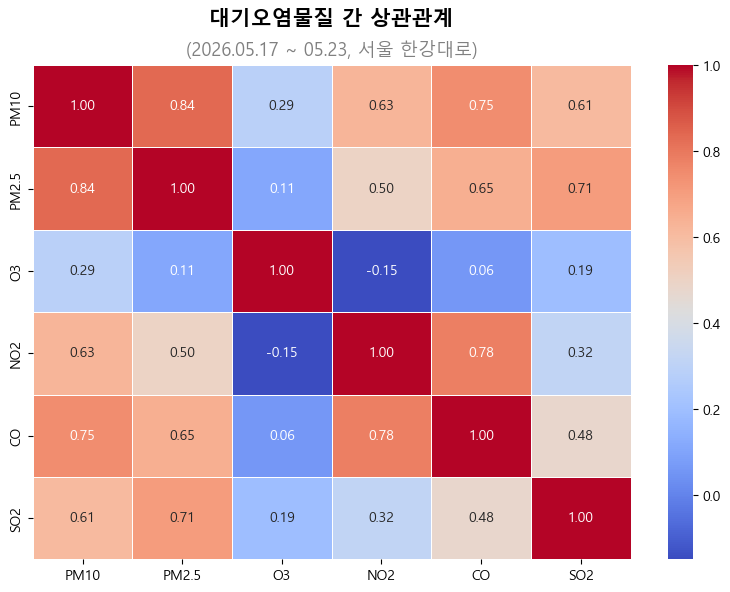

In [71]:
target_cols = ["PM10", "PM25", "O3", "NO2", "CO", "SO2"]
corr_matrix = df[target_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", 
            fmt=".2f", linewidths=0.5,
            xticklabels=["PM10", "PM2.5", "O3", "NO2", "CO", "SO2"],
            yticklabels=["PM10", "PM2.5", "O3", "NO2", "CO", "SO2"])

plt.text(0.5, 1.08, "대기오염물질 간 상관관계",
         transform=plt.gca().transAxes, ha="center", 
         fontsize=15, fontweight="bold")
plt.text(0.5, 1.02, "(2026.05.17 ~ 05.23, 서울 한강대로)",
         transform=plt.gca().transAxes, ha="center", 
         fontsize=13, color="gray")

plt.tight_layout()
plt.show()

## 📝 결과 해석

<span style="color: gray; font-size: 0.85em;">
히트맵 읽는 법: 빨강(1.0) = 함께 올라감 / 파랑(-1.0) = 반대로 움직임 / 흰색(0) = 관계 없음
</span>

**주요 발견 (히트맵)**

- **PM10 ↔ PM2.5 (0.84)** → 두 물질이 거의 함께 움직임
- **PM2.5 ↔ CO (0.65)** → 차량 배기가스(CO)가 PM2.5에 영향 가능성
- **PM2.5 ↔ NO2 (0.50)** → 이산화질소도 PM2.5와 어느 정도 관계 있음
- **O3 ↔ NO2 (-0.15)** → 광화학 반응으로 반대로 움직임

아래 산점도로 PM2.5와 CO, NO2의 관계를 더 자세히 확인합니다.

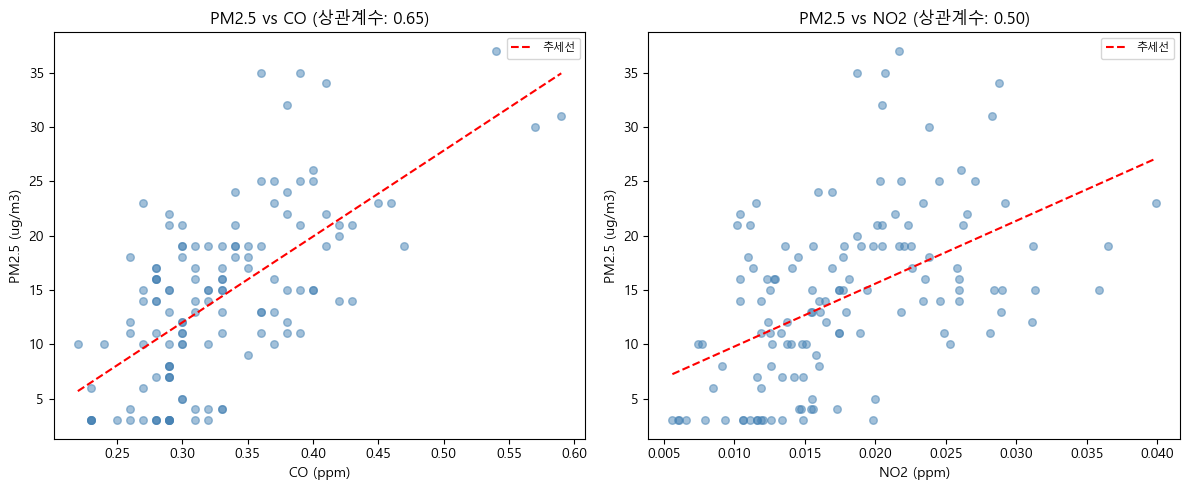

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# PM2.5 vs CO
axes[0].scatter(df["CO"], df["PM25"], alpha=0.5, color="steelblue", s=30)
axes[0].set_xlabel("CO (ppm)")
axes[0].set_ylabel("PM2.5 (ug/m3)")

# 추세선
mask = df[["CO", "PM25"]].dropna()
z = np.polyfit(mask["CO"], mask["PM25"], 1)
p = np.poly1d(z)
x_range = np.linspace(mask["CO"].min(), mask["CO"].max(), 100)
axes[0].plot(x_range, p(x_range), "r--", linewidth=1.5, label="추세선")
axes[0].legend(fontsize=8)
axes[0].set_title(f"PM2.5 vs CO (상관계수: {df['CO'].corr(df['PM25']):.2f})")

# PM2.5 vs NO2
axes[1].scatter(df["NO2"], df["PM25"], alpha=0.5, color="steelblue", s=30)
axes[1].set_xlabel("NO2 (ppm)")
axes[1].set_ylabel("PM2.5 (ug/m3)")

mask2 = df[["NO2", "PM25"]].dropna()
z2 = np.polyfit(mask2["NO2"], mask2["PM25"], 1)
p2 = np.poly1d(z2)
x_range2 = np.linspace(mask2["NO2"].min(), mask2["NO2"].max(), 100)
axes[1].plot(x_range2, p2(x_range2), "r--", linewidth=1.5, label="추세선")
axes[1].legend(fontsize=8)
axes[1].set_title(f"PM2.5 vs NO2 (상관계수: {df['NO2'].corr(df['PM25']):.2f})")

plt.tight_layout()
plt.show()

**📊 산점도 해석**

- **PM2.5 vs CO (r=0.65)** → CO가 높을수록 PM2.5도 높아지는 경향
- **PM2.5 vs NO2 (r=0.50)** → NO2도 PM2.5와 어느 정도 관계 있음

**결론:** PM2.5는 CO, NO2와 양의 상관관계를 보입니다.  
차량 배기가스와의 연관성이 의심되나, 실제 교통량 데이터와의 비교 분석이 추가로 필요합니다.

<span style="color: gray; font-size: 0.85em;">
※ 본 분석은 6일치 데이터 기준으로, 통계적 유의성 확보를 위해 장기 데이터 추가 분석이 필요합니다.
</span>

## 4. 🕐 시간대별 PM2.5 패턴 분석

하루 중 어느 시간대에 PM2.5가 높은지 확인합니다.  
6일치 데이터를 시간대(0~23시)별로 평균 내어 경향성을 파악합니다.

<span style="color: gray; font-size: 0.85em;">
※ 시간대별 데이터가 6개씩으로 적어 통계적 유의성은 낮으나 경향성 파악 목적으로 분석합니다.
</span>

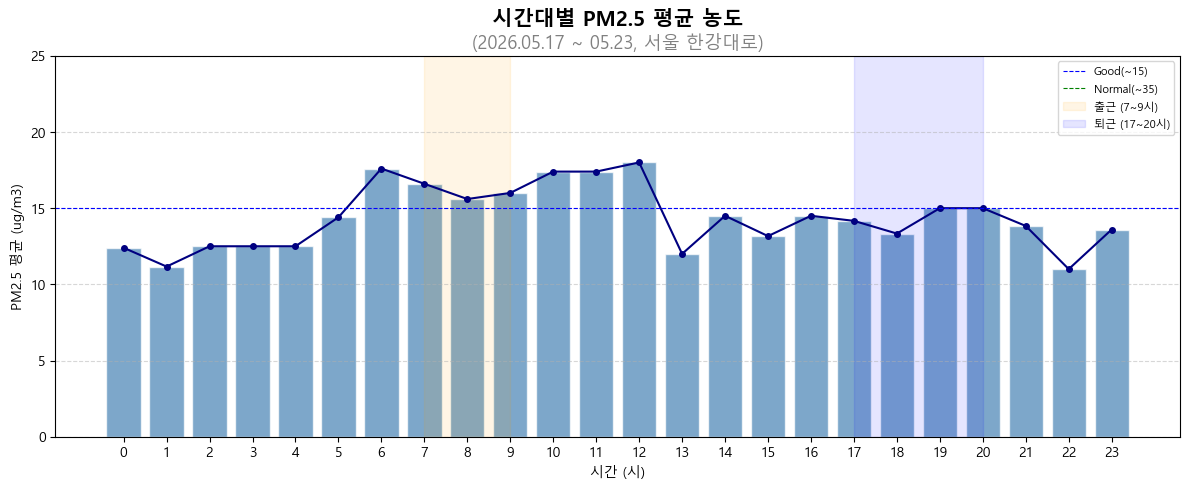


가장 높은 시간대: 12시 (18.0 ug/m3)
가장 낮은 시간대: 22시 (11.0 ug/m3)


In [79]:
df["시간"] = df["날짜"].dt.hour

hourly = df.groupby("시간")["PM25"].mean()

plt.figure(figsize=(12, 5))
plt.bar(hourly.index, hourly.values, color="steelblue", alpha=0.7, edgecolor="white")
plt.plot(hourly.index, hourly.values, "o-", color="navy", linewidth=1.5, markersize=4)

plt.ylim(0, 25)
plt.axhline(y=15, color="blue",  linestyle="--", linewidth=0.8, label="Good(~15)")
plt.axhline(y=35, color="green", linestyle="--", linewidth=0.8, label="Normal(~35)")

plt.text(0.5, 1.08, "시간대별 PM2.5 평균 농도",
         transform=plt.gca().transAxes, ha="center",
         fontsize=15, fontweight="bold")
plt.text(0.5, 1.02, "(2026.05.17 ~ 05.23, 서울 한강대로)",
         transform=plt.gca().transAxes, ha="center",
         fontsize=13, color="gray")

plt.xlabel("시간 (시)")
plt.ylabel("PM2.5 평균 (ug/m3)")
plt.xticks(range(0, 24))
plt.grid(axis="y", linestyle="--", alpha=0.5)
# 출퇴근 구간 배경색
plt.axvspan(7, 9,   alpha=0.1, color="orange", label="출근 (7~9시)")
plt.axvspan(17, 20, alpha=0.1, color="blue",   label="퇴근 (17~20시)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"\n가장 높은 시간대: {hourly.idxmax()}시 ({hourly.max():.1f} ug/m3)")
print(f"가장 낮은 시간대: {hourly.idxmin()}시 ({hourly.min():.1f} ug/m3)")

**📊 시간대별 해석**

- 가장 높은 시간대: **12시 (18.0 ug/m3)**
- 가장 낮은 시간대: **22시 (11.0 ug/m3)**
- 출근 시간대(7~9시)에 소폭 상승하는 경향이 보임
- 퇴근 시간대(17~20시)는 뚜렷한 피크 없음

**한계점**
- 6일치 데이터로 평균이 희석되었을 가능성
- 기상 조건(비, 바람 등)이 결과에 영향을 미쳤을 가능성

<span style="color: gray; font-size: 0.85em;">
※ 6일치 데이터 기준으로 경향성 파악 목적이며, 확정적 결론 도출을 위해 장기 데이터 분석이 필요합니다.
</span>